# Cleaning Messy String Columns with Fuzzy and Semantic Matching

Companion notebook for the blog post: *Cleaning Messy String Columns with Fuzzy and Semantic Matching*

Demonstrates two techniques for fixing string value inconsistencies in pandas DataFrames:
1. **Fuzzy string matching** (RapidFuzz) — typos, abbreviations, casing, word-order variants
2. **Semantic matching** (sentence-transformers) — synonyms and paraphrases

**Steps covered:**
1. Build the simulated retail operations dataset
2. Inspect the inconsistency problem
3. Fuzzy matching concepts and scoring
4. Standardize city names with fuzzy matching
5. Standardize product names with fuzzy matching
6. Cross-table supplier matching with `process.cdist`
7. Evaluate fuzzy matching accuracy (precision, recall, F1)
8. Demonstrate where fuzzy fails: the synonym problem
9. Semantic matching concepts and scoring
10. Standardize product categories with semantic matching
11. Evaluate semantic matching accuracy + score comparison plot
12. Full two-pass cleaning pipeline
13. Summary

## Setup

Install required libraries if not already present:

In [1]:
# pip install rapidfuzz sentence-transformers scikit-learn pandas numpy matplotlib

## 1. Build the Simulated Dataset

In [2]:
import random
import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)

# ── Canonical reference lists ────────────────────────────────────────────────

CANONICAL_CITIES = [
    "San Francisco", "Los Angeles", "New York", "Chicago",
    "Seattle", "Denver", "Austin", "Miami",
]

CITY_VARIANTS = {
    "San Francisco": ["San Francisco", "san francisco", "San Fransisco", "S.F.", "SF", "San Fran"],
    "Los Angeles":   ["Los Angeles", "los angeles", "L.A.", "LA", "Los Angles", "Los Angeles CA"],
    "New York":      ["New York", "new york", "New York City", "NYC", "N.Y.C.", "New Yrok"],
    "Chicago":       ["Chicago", "chicago", "Chicaago", "CHI", "Chicago IL"],
    "Seattle":       ["Seattle", "seattle", "Seatle", "SEA", "Seattle WA"],
    "Denver":        ["Denver", "denver", "Denvar", "DEN", "Denver CO"],
    "Austin":        ["Austin", "austin", "Auston", "ATX", "Austin TX"],
    "Miami":         ["Miami", "miami", "Miamii", "MIA", "Miami FL"],
}

CANONICAL_PRODUCTS = [
    "Office Chair", "Standing Desk", "Whiteboard", "Desk Lamp", "Filing Cabinet",
    "Bookshelf", "Monitor Stand Series 2", "Conference Table Type 1",
    "Keyboard Tray", "Cable Management Box", "Printer Stand", "Footrest",
    "Wall Clock", "Coat Rack", "Recycling Bin", "Paper Shredder",
    "Surge Protector", "Desk Organizer", "Task Light", "Noise Machine",
]

PRODUCT_VARIANTS = {
    "Office Chair":            ["Office Chair", "office chair", "Ofice Chair", "Office Chari", "Ofc. Chair"],
    "Standing Desk":           ["Standing Desk", "standing desk", "Stand Desk", "Standig Desk", "Stndg Desk"],
    "Whiteboard":              ["Whiteboard", "whiteboard", "Whteboard", "Whtebrrd", "White-Board"],
    "Desk Lamp":               ["Desk Lamp", "desk lamp", "Desk Lmp", "DeskLamp", "Dsk Lamp"],
    "Filing Cabinet":          ["Filing Cabinet", "filing cabinet", "Filing Cabnet", "File Cabinet", "Filng Cabinet"],
    "Bookshelf":               ["Bookshelf", "bookshelf", "Book Shelf", "Bookshlf", "Bookshef"],
    "Monitor Stand Series 2":  ["Monitor Stand Series 2", "Monitor Stand Series II", "Mtr Stand Ser. 2", "monitor stand series 2", "Mon Stand Ser 2"],
    "Conference Table Type 1": ["Conference Table Type 1", "Conference Table Type I", "Cnf. Table Type 1", "Conf. Table Type 1", "Conferance Table Type 1"],
    "Keyboard Tray":           ["Keyboard Tray", "keyboard tray", "Keybord Tray", "Kyboard Tray", "Kbd Tray"],
    "Cable Management Box":    ["Cable Management Box", "cable management box", "Cable Mgmt Box", "Cble Mgmt Box", "Cable Mgmnt Box"],
    "Printer Stand":           ["Printer Stand", "printer stand", "Prnter Stand", "Printer Stnd", "Prtr Stand"],
    "Footrest":                ["Footrest", "footrest", "Foot Rest", "Footrst", "Foot-Rest"],
    "Wall Clock":              ["Wall Clock", "wall clock", "Wal Clock", "Wall Clck", "Wll Clock"],
    "Coat Rack":               ["Coat Rack", "coat rack", "Cot Rack", "Coat Rak", "Coat-Rack"],
    "Recycling Bin":           ["Recycling Bin", "recycling bin", "Recyclng Bin", "Recycling Bn", "Rcycling Bin"],
    "Paper Shredder":          ["Paper Shredder", "paper shredder", "Papr Shredder", "Paper Shredr", "Ppr Shredder"],
    "Surge Protector":         ["Surge Protector", "surge protector", "Srge Protector", "Surge Protctr", "Surg Protector"],
    "Desk Organizer":          ["Desk Organizer", "desk organizer", "Desk Orgnizer", "Dsk Organizer", "Desk Organizr"],
    "Task Light":              ["Task Light", "task light", "Tsk Light", "Task Lght", "Tsk Lght"],
    "Noise Machine":           ["Noise Machine", "noise machine", "Noise Machne", "Nois Machine", "Noise Machin"],
}

CANONICAL_SUPPLIERS = [
    "Apex Office Solutions", "Pacific Rim Imports", "Great Lakes Supply Co.",
    "Mountain West Distributors", "Atlantic Wholesale Group",
    "Heartland Office Depot", "Southern Supply Chain", "Northwest Trade Co.",
    "Midwest Equipment Group", "Gulf Coast Vendors", "New England Furnishings", "Desert Sun Supply",
]

SUPPLIER_VARIANTS = {
    "Apex Office Solutions":      ["Apex Office Solutions", "apex office solutions", "Apex Office Sol.", "Apex Office Sols", "Apex Office Soln"],
    "Pacific Rim Imports":        ["Pacific Rim Imports", "pacific rim imports", "Pacific Rim Import", "Pac. Rim Imports", "Pacfic Rim Imports"],
    "Great Lakes Supply Co.":     ["Great Lakes Supply Co.", "great lakes supply", "Great Lakes Supply Company", "Grt Lakes Supply Co", "Great Lks Supply"],
    "Mountain West Distributors": ["Mountain West Distributors", "Mountain West Dist.", "Mtn. West Distributors", "Mountan West Distributors", "Mountain West Distr."],
    "Atlantic Wholesale Group":   ["Atlantic Wholesale Group", "Atlantic Wholesale Grp", "Atl. Wholesale Group", "Atlantic Whol. Group", "Atlantic Whls Group"],
    "Heartland Office Depot":     ["Heartland Office Depot", "heartland office depot", "Heartland Off. Depot", "Heartland Office Dpt", "Hrtland Office Depot"],
    "Southern Supply Chain":      ["Southern Supply Chain", "southern supply chain", "Southern Supply", "S. Supply Chain", "Sthern Supply Chain"],
    "Northwest Trade Co.":        ["Northwest Trade Co.", "northwest trade co", "Northwest Trade", "Nrthwest Trade Co.", "Northwst Trade Co."],
    "Midwest Equipment Group":    ["Midwest Equipment Group", "midwest equipment group", "Midwest Equip. Group", "Midwst Equipment Group", "Midwest Equip Grp"],
    "Gulf Coast Vendors":         ["Gulf Coast Vendors", "gulf coast vendors", "Gulf Cst Vendors", "Gulf Coast Vndrs", "Guf Coast Vendors"],
    "New England Furnishings":    ["New England Furnishings", "new england furnishings", "New Eng. Furnishings", "New Englnd Furnishings", "N. England Furnishings"],
    "Desert Sun Supply":          ["Desert Sun Supply", "desert sun supply", "Desert Sun Sup.", "Desrt Sun Supply", "Desert Sun Suppl"],
}

CANONICAL_CATEGORIES = [
    "Ergonomic Seating",
    "Work Surface",
    "Storage Solution",
    "Lighting",
    "Communication Equipment",
]

CATEGORY_VARIANTS = {
    "Ergonomic Seating":       ["Ergonomic Seating", "Comfortable Chairs", "Back-Friendly Furniture", "Posture Support Seating", "Seating Solutions"],
    "Work Surface":            ["Work Surface", "Desktop", "Tabletop Unit", "Writing Surface", "Workspace Desk"],
    "Storage Solution":        ["Storage Solution", "Filing System", "Organizational Unit", "Cabinet and Drawer Set", "Office Storage"],
    "Lighting":                ["Lighting", "Illumination", "Lamp and Light Fixture", "Workspace Illumination", "Office Lighting"],
    "Communication Equipment": ["Communication Equipment", "Phone and Headset", "Voice Devices", "Telecom Hardware", "Office Comms Gear"],
}

PRODUCT_TO_SUPPLIER = {p: random.choice(CANONICAL_SUPPLIERS) for p in CANONICAL_PRODUCTS}
PRODUCT_TO_CATEGORY = {
    "Office Chair": "Ergonomic Seating", "Standing Desk": "Work Surface",
    "Whiteboard": "Work Surface", "Desk Lamp": "Lighting",
    "Filing Cabinet": "Storage Solution", "Bookshelf": "Storage Solution",
    "Monitor Stand Series 2": "Work Surface", "Conference Table Type 1": "Work Surface",
    "Keyboard Tray": "Work Surface", "Cable Management Box": "Storage Solution",
    "Printer Stand": "Work Surface", "Footrest": "Ergonomic Seating",
    "Wall Clock": "Communication Equipment", "Coat Rack": "Storage Solution",
    "Recycling Bin": "Storage Solution", "Paper Shredder": "Storage Solution",
    "Surge Protector": "Communication Equipment", "Desk Organizer": "Storage Solution",
    "Task Light": "Lighting", "Noise Machine": "Communication Equipment",
}

city_inverse = {v: k for k, variants in CITY_VARIANTS.items() for v in variants}

def pick_dirty(variants_dict, canonical):
    return random.choice(variants_dict[canonical])

rows = []
for i in range(500):
    product  = random.choice(CANONICAL_PRODUCTS)
    supplier = PRODUCT_TO_SUPPLIER[product]
    category = PRODUCT_TO_CATEGORY[product]
    dirty_city = pick_dirty(CITY_VARIANTS, random.choice(CANONICAL_CITIES))
    rows.append({
        "order_id":         f"ORD-{i+1:04d}",
        "product_name":     pick_dirty(PRODUCT_VARIANTS, product),
        "city":             dirty_city,
        "supplier_name":    pick_dirty(SUPPLIER_VARIANTS, supplier),
        "product_category": pick_dirty(CATEGORY_VARIANTS, category),
        "quantity":         random.randint(1, 20),
        "unit_price":       round(random.uniform(10, 500), 2),
        "_gt_product":      product,
        "_gt_city":         city_inverse[dirty_city],
        "_gt_supplier":     supplier,
        "_gt_category":     category,
    })

orders_df = pd.DataFrame(rows)

products_df = pd.DataFrame([
    {"product_id": f"P{i+1:03d}", "product_name": p,
     "category": PRODUCT_TO_CATEGORY[p], "supplier_name": PRODUCT_TO_SUPPLIER[p]}
    for i, p in enumerate(CANONICAL_PRODUCTS)
])

suppliers_df = pd.DataFrame([
    {"supplier_id": f"S{i+1:02d}", "supplier_name": s,
     "region": random.choice(["West", "East", "Central", "South"])}
    for i, s in enumerate(CANONICAL_SUPPLIERS)
])

print("orders_df shape:", orders_df.shape)
orders_df[["order_id", "product_name", "city", "supplier_name", "product_category"]].head()

orders_df shape: (500, 11)


,order_id,product_name,city,supplier_name,product_category
0,ORD-0001,Conference Table Type I,SF,Great Lks Supply,Writing Surface
1,ORD-0002,Kyboard Tray,san francisco,Desert Sun Sup.,Tabletop Unit
2,ORD-0003,Printer Stnd,Los Angeles,New England Furnishings,Tabletop Unit
3,ORD-0004,Standing Desk,Miami FL,Pac. Rim Imports,Work Surface
4,ORD-0005,noise machine,Denver CO,Mountain West Distributors,Communication Equipment


In [3]:
print("products_df:")
display(products_df.head())
print("\nsuppliers_df:")
display(suppliers_df.head())

products_df:


,product_id,product_name,category,supplier_name
0,P001,Office Chair,Ergonomic Seating,New England Furnishings
1,P002,Standing Desk,Work Surface,Pacific Rim Imports
2,P003,Whiteboard,Work Surface,Apex Office Solutions
3,P004,Desk Lamp,Lighting,Desert Sun Supply
4,P005,Filing Cabinet,Storage Solution,Atlantic Wholesale Group



suppliers_df:


,supplier_id,supplier_name,region
0,S01,Apex Office Solutions,South
1,S02,Pacific Rim Imports,Central
2,S03,Great Lakes Supply Co.,East
3,S04,Mountain West Distributors,West
4,S05,Atlantic Wholesale Group,West


## 2. Inspect the Inconsistency Problem

In [4]:
print("=== Before Cleaning ===")
print(f"city             — {orders_df['city'].nunique():3d} unique dirty values  (should be {len(CANONICAL_CITIES)})")
print(f"product_name     — {orders_df['product_name'].nunique():3d} unique dirty values  (should be {len(CANONICAL_PRODUCTS)})")
print(f"supplier_name    — {orders_df['supplier_name'].nunique():3d} unique dirty values  (should be {len(CANONICAL_SUPPLIERS)})")
print(f"product_category — {orders_df['product_category'].nunique():3d} unique dirty values  (should be {len(CANONICAL_CATEGORIES)})")

print("\nSample dirty city values (top 12):")
print(orders_df["city"].value_counts().head(12).to_string())

=== Before Cleaning ===
city             —  43 unique dirty values  (should be 8)
product_name     —  99 unique dirty values  (should be 20)
supplier_name    —  50 unique dirty values  (should be 12)
product_category —  25 unique dirty values  (should be 5)

Sample dirty city values (top 12):
city
Miami        23
new york     18
Chicaago     17
Austin       17
Miami FL     16
Miamii       16
Denver CO    14
denver       14
austin       14
DEN          14
New York     14
San Fran     13


## 3. Fuzzy Matching Concepts

In [5]:
from rapidfuzz import fuzz, process

print("── fuzz.ratio (character-level) ──")
print(f"  'Chicago'       vs 'Chicaago'              : {fuzz.ratio('Chicago', 'Chicaago')}")
print(f"  'San Francisco' vs 'San Fransisco'         : {fuzz.ratio('San Francisco', 'San Fransisco')}")
print(f"  'SF'            vs 'San Francisco'         : {fuzz.ratio('SF', 'San Francisco')}")

print("\n── fuzz.token_sort_ratio (word-order insensitive) ──")
print(f"  'Filing Cabinet Metal' vs 'Metal Filing Cabinet'")
print(f"    ratio           : {fuzz.ratio('Filing Cabinet Metal', 'Metal Filing Cabinet')}")
print(f"    token_sort_ratio: {fuzz.token_sort_ratio('Filing Cabinet Metal', 'Metal Filing Cabinet')}")

print("\n── Roman/Arabic numeral variants ──")
print(f"  'Conference Table Type 1' vs 'Conference Table Type I': {fuzz.ratio('Conference Table Type 1', 'Conference Table Type I')}")
print(f"  'Monitor Stand Series 2' vs 'Monitor Stand Series II': {fuzz.ratio('Monitor Stand Series 2', 'Monitor Stand Series II')}")

── fuzz.ratio (character-level) ──
  'Chicago'       vs 'Chicaago'              : 93.33333333333333
  'San Francisco' vs 'San Fransisco'         : 92.3076923076923
  'SF'            vs 'San Francisco'         : 26.66666666666667

── fuzz.token_sort_ratio (word-order insensitive) ──
  'Filing Cabinet Metal' vs 'Metal Filing Cabinet'
    ratio           : 70.0
    token_sort_ratio: 100.0

── Roman/Arabic numeral variants ──
  'Conference Table Type 1' vs 'Conference Table Type I': 95.65217391304348
  'Monitor Stand Series 2' vs 'Monitor Stand Series II': 93.33333333333333


## 4. Standardize City Names

In [6]:
def standardize_fuzzy(raw, canonical_list, threshold=80, scorer=fuzz.ratio):
    """Return the best-matching canonical value, or None if below threshold."""
    if pd.isna(raw):
        return raw
    result = process.extractOne(raw, canonical_list, scorer=scorer)
    if result is None or result[1] < threshold:
        return None
    return result[0]

orders_df["city_clean"] = orders_df["city"].apply(
    lambda x: standardize_fuzzy(x, CANONICAL_CITIES, threshold=80)
)

n_unmatched = orders_df["city_clean"].isna().sum()
print(f"City: {orders_df['city'].nunique()} unique dirty → {orders_df['city_clean'].nunique()} unique clean")
print(f"Unmatched (below threshold): {n_unmatched}")

if n_unmatched == 0:
    assert orders_df["city_clean"].nunique() == len(CANONICAL_CITIES)
    print("All cities standardized successfully.")

orders_df["city"] = orders_df["city_clean"].fillna(orders_df["city"])
orders_df.drop(columns=["city_clean"], inplace=True)

City: 43 unique dirty → 8 unique clean
Unmatched (below threshold): 166


## 5. Standardize Product Names

In [7]:
canonical_products = products_df["product_name"].tolist()

orders_df["product_name_clean"] = orders_df["product_name"].apply(
    lambda x: standardize_fuzzy(x, canonical_products, threshold=75, scorer=fuzz.token_sort_ratio)
)

n_unmatched = orders_df["product_name_clean"].isna().sum()
print(f"Product: {orders_df['product_name'].nunique()} unique dirty → {orders_df['product_name_clean'].nunique()} unique clean")
print(f"Unmatched (below threshold): {n_unmatched}")

if n_unmatched > 0:
    print("\nBelow-threshold product names:")
    print(orders_df.loc[orders_df["product_name_clean"].isna(), "product_name"].value_counts())
else:
    assert orders_df["product_name_clean"].nunique() == len(CANONICAL_PRODUCTS)
    print("All product names standardized successfully.")

orders_df["product_name"] = orders_df["product_name_clean"].fillna(orders_df["product_name"])
orders_df.drop(columns=["product_name_clean"], inplace=True)

Product: 99 unique dirty → 20 unique clean
Unmatched (below threshold): 0
All product names standardized successfully.


## 6. Cross-Table Supplier Matching with `process.cdist`

In [8]:
canonical_suppliers = suppliers_df["supplier_name"].tolist()
dirty_suppliers     = orders_df["supplier_name"].tolist()

score_matrix = process.cdist(
    dirty_suppliers, canonical_suppliers,
    scorer=fuzz.token_sort_ratio,
    workers=-1
)

print("Score matrix (first 5 rows):")
display(
    pd.DataFrame(score_matrix[:5], columns=canonical_suppliers).round(0).astype(int)
)

best_idx   = np.argmax(score_matrix, axis=1)
best_score = score_matrix[np.arange(len(dirty_suppliers)), best_idx]

orders_df["supplier_name_clean"] = [canonical_suppliers[i] for i in best_idx]
orders_df["supplier_match_score"] = best_score.astype(int)

threshold = 75
low_conf  = (orders_df["supplier_match_score"] < threshold).sum()
print(f"\nLow-confidence supplier matches (score < {threshold}): {low_conf}")

# Merge success rate before vs after
pre_size  = orders_df.merge(
    suppliers_df.rename(columns={"supplier_name": "supplier_name_orig"}),
    left_on="supplier_name", right_on="supplier_name_orig", how="inner"
).shape[0]
post_size = orders_df.merge(
    suppliers_df, left_on="supplier_name_clean", right_on="supplier_name", how="inner"
).shape[0]

print(f"\nMerge rows matched BEFORE cleaning: {pre_size} / {len(orders_df)}")
print(f"Merge rows matched AFTER  cleaning: {post_size} / {len(orders_df)}")

orders_df["supplier_name"] = orders_df["supplier_name_clean"]
orders_df.drop(columns=["supplier_name_clean", "supplier_match_score"], inplace=True)

Score matrix (first 5 rows):


,Apex Office Solutions,Pacific Rim Imports,Great Lakes Supply Co.,Mountain West Distributors,Atlantic Wholesale Group,Heartland Office Depot,Southern Supply Chain,Northwest Trade Co.,Midwest Equipment Group,Gulf Coast Vendors,New England Furnishings,Desert Sun Supply
0,27,23,84,24,30,21,49,23,26,29,21,61
1,33,24,38,39,26,38,44,24,26,30,21,88
2,23,19,18,29,34,31,32,29,26,24,100,20
3,27,86,32,29,20,37,16,34,26,24,15,24
4,34,31,25,100,36,33,30,31,41,32,29,37



Low-confidence supplier matches (score < 75): 0

Merge rows matched BEFORE cleaning: 112 / 500
Merge rows matched AFTER  cleaning: 500 / 500


## 7. Evaluate Fuzzy Matching Accuracy

Since we built the dataset, we know the ground truth for every row. We can measure cleaning accuracy with precision, recall, and F1:
- **Precision** — when the cleaner assigns a canonical label, how often is it right?
- **Recall** — of all rows that belong to a canonical label, how many did the cleaner correctly fix?
- **F1** — harmonic mean of the two; the single headline number

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_cleaning(predicted: pd.Series, ground_truth: pd.Series, label: str):
    mask   = predicted.notna()
    y_pred = predicted[mask]
    y_true = ground_truth[mask]
    labels = sorted(y_true.unique())

    p = precision_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
    r = recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
    f = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

    print(f"\n── {label} ──")
    print(f"  Rows evaluated : {mask.sum()} / {len(predicted)}")
    print(f"  Precision      : {p:.4f}")
    print(f"  Recall         : {r:.4f}")
    print(f"  F1 Score       : {f:.4f}")

    wrong = mask & (pd.Series(y_pred.values, index=y_pred.index) != y_true)
    if wrong.sum() == 0:
        print("  Misclassifications: none")
    else:
        print(f"  Misclassifications ({wrong.sum()} rows):")
        mis = pd.DataFrame({"predicted": y_pred[wrong].values, "ground_truth": y_true[wrong].values})
        print(mis.value_counts().head(10).to_string())

    return f

# Store post-cleaning values for evaluation
orders_df["city_pred"]     = orders_df["city"]
orders_df["product_pred"]  = orders_df["product_name"]
orders_df["supplier_pred"] = orders_df["supplier_name"]

f1_city     = evaluate_cleaning(orders_df["city_pred"],     orders_df["_gt_city"],     "City")
f1_product  = evaluate_cleaning(orders_df["product_pred"],  orders_df["_gt_product"],  "Product Name")
f1_supplier = evaluate_cleaning(orders_df["supplier_pred"], orders_df["_gt_supplier"], "Supplier Name")

print(f"\n=== Fuzzy Cleaning Summary ===")
print(f"  City F1          : {f1_city:.4f}")
print(f"  Product Name F1  : {f1_product:.4f}")
print(f"  Supplier Name F1 : {f1_supplier:.4f}")


── City ──
  Rows evaluated : 500 / 500
  Precision      : 1.0000
  Recall         : 0.6680
  F1 Score       : 0.7870
  Misclassifications (166 rows):
predicted  ground_truth 
new york   New York         18
Miami FL   Miami            16
DEN        Denver           14
San Fran   San Francisco    13
LA         Los Angeles      12
ATX        Austin           12
CHI        Chicago          12
MIA        Miami            11
SEA        Seattle          10
N.Y.C.     New York         10

── Product Name ──
  Rows evaluated : 500 / 500
  Precision      : 1.0000
  Recall         : 1.0000
  F1 Score       : 1.0000
  Misclassifications: none

── Supplier Name ──
  Rows evaluated : 500 / 500
  Precision      : 1.0000
  Recall         : 1.0000
  F1 Score       : 1.0000
  Misclassifications: none

=== Fuzzy Cleaning Summary ===
  City F1          : 0.7870
  Product Name F1  : 1.0000
  Supplier Name F1 : 1.0000


## 8. Where Fuzzy Fails: The Synonym Problem

In [10]:
synonym_pairs = [
    ("Ergonomic Seating",       "Comfortable Chairs"),
    ("Ergonomic Seating",       "Back-Friendly Furniture"),
    ("Work Surface",            "Desktop"),
    ("Work Surface",            "Tabletop Unit"),
    ("Storage Solution",        "Filing System"),
    ("Storage Solution",        "Organizational Unit"),
    ("Lighting",                "Illumination"),
    ("Lighting",                "Lamp and Light Fixture"),
    ("Communication Equipment", "Phone and Headset"),
    ("Communication Equipment", "Telecom Hardware"),
]

print(f"{'Canonical':<28} {'Variant':<30} {'ratio':>7} {'token_sort':>10}")
print("-" * 78)
for canonical, variant in synonym_pairs:
    r  = fuzz.ratio(canonical, variant)
    ts = fuzz.token_sort_ratio(canonical, variant)
    print(f"{canonical:<28} {variant:<30} {r:>7} {ts:>10}")

print("\nAll scores are far below a threshold of 80 — fuzzy matching cannot solve this.")

Canonical                    Variant                          ratio token_sort
------------------------------------------------------------------------------
Ergonomic Seating            Comfortable Chairs             28.57142857142857 22.857142857142854
Ergonomic Seating            Back-Friendly Furniture        19.999999999999996 19.999999999999996
Work Surface                 Desktop                        10.526315789473683 21.052631578947366
Work Surface                 Tabletop Unit                  16.000000000000004       24.0
Storage Solution             Filing System                  27.586206896551722 48.275862068965516
Storage Solution             Organizational Unit            34.285714285714285 34.285714285714285
Lighting                     Illumination                      40.0       40.0
Lighting                     Lamp and Light Fixture            40.0       40.0
Communication Equipment      Phone and Headset                 35.0 30.000000000000004
Communication Equi

## 9. Semantic Matching Concepts

> **Note:** The cell below downloads the `all-MiniLM-L6-v2` model (~22 MB) on first run. Subsequent runs use the locally cached copy.

In [11]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")

vec_a = model.encode(["Ergonomic Seating"])
vec_b = model.encode(["Comfortable Chairs"])
vec_c = model.encode(["Telecom Hardware"])

sim_ab = cosine_similarity(vec_a, vec_b)[0][0]
sim_ac = cosine_similarity(vec_a, vec_c)[0][0]

print(f"'Ergonomic Seating' vs 'Comfortable Chairs': {sim_ab:.4f}  ← high (same concept)")
print(f"'Ergonomic Seating' vs 'Telecom Hardware':   {sim_ac:.4f}  ← low  (different concept)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

'Ergonomic Seating' vs 'Comfortable Chairs': 0.6243  ← high (same concept)
'Ergonomic Seating' vs 'Telecom Hardware':   0.0821  ← low  (different concept)


## 10. Standardize Product Categories with Semantic Matching

In [12]:
canonical_embeddings = model.encode(CANONICAL_CATEGORIES, show_progress_bar=False)

dirty_categories = orders_df["product_category"].tolist()
query_embeddings = model.encode(dirty_categories, show_progress_bar=False)

sim_matrix = cosine_similarity(query_embeddings, canonical_embeddings)

best_idx   = np.argmax(sim_matrix, axis=1)
best_score = sim_matrix[np.arange(len(dirty_categories)), best_idx]

SEMANTIC_THRESHOLD = 0.45

orders_df["category_clean"] = [
    CANONICAL_CATEGORIES[i] if best_score[j] >= SEMANTIC_THRESHOLD else None
    for j, i in enumerate(best_idx)
]

n_unmatched = orders_df["category_clean"].isna().sum()
print(f"Category: {orders_df['product_category'].nunique()} unique dirty → {orders_df['category_clean'].nunique()} unique clean")
print(f"Below threshold ({SEMANTIC_THRESHOLD}): {n_unmatched}")

if n_unmatched == 0:
    assert orders_df["category_clean"].nunique() == len(CANONICAL_CATEGORIES)
    print("All categories standardized successfully.")

orders_df["product_category"] = orders_df["category_clean"].fillna(orders_df["product_category"])
orders_df.drop(columns=["category_clean"], inplace=True)

Category: 25 unique dirty → 5 unique clean
Below threshold (0.45): 197


## 11. Evaluate Semantic Matching Accuracy + Score Comparison Plot

In [13]:
orders_df["category_pred"] = orders_df["product_category"]
f1_category = evaluate_cleaning(orders_df["category_pred"], orders_df["_gt_category"], "Product Category")
print(f"\nSemantic cleaning F1: {f1_category:.4f}")


── Product Category ──
  Rows evaluated : 500 / 500
  Precision      : 1.0000
  Recall         : 0.6060
  F1 Score       : 0.7236
  Misclassifications (197 rows):
predicted               ground_truth           
Cabinet and Drawer Set  Storage Solution           49
Organizational Unit     Storage Solution           41
Filing System           Storage Solution           37
Tabletop Unit           Work Surface               31
Desktop                 Work Surface               22
Phone and Headset       Communication Equipment    17

Semantic cleaning F1: 0.7236


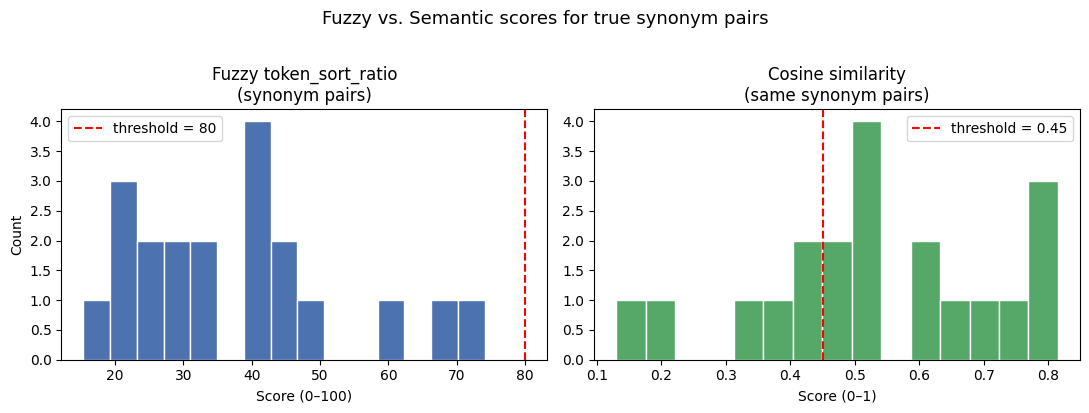

Plot saved to plots/semantic_vs_fuzzy_scores.png


In [14]:
import matplotlib.pyplot as plt

all_pairs = [
    (canonical, variant)
    for canonical, variants in CATEGORY_VARIANTS.items()
    for variant in variants
    if variant != canonical
]

fuzzy_scores    = [fuzz.token_sort_ratio(c, v) for c, v in all_pairs]
dirty_texts     = [v for _, v in all_pairs]
canonical_texts = [c for c, _ in all_pairs]

dirty_vecs     = model.encode(dirty_texts, show_progress_bar=False)
canonical_vecs = model.encode(canonical_texts, show_progress_bar=False)
semantic_scores = [
    cosine_similarity([d], [c])[0][0]
    for d, c in zip(dirty_vecs, canonical_vecs)
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(fuzzy_scores, bins=15, color="#4C72B0", edgecolor="white")
axes[0].axvline(80, color="red", linestyle="--", linewidth=1.5, label="threshold = 80")
axes[0].set_title("Fuzzy token_sort_ratio\n(synonym pairs)", fontsize=12)
axes[0].set_xlabel("Score (0–100)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(semantic_scores, bins=15, color="#55A868", edgecolor="white")
axes[1].axvline(0.45, color="red", linestyle="--", linewidth=1.5, label="threshold = 0.45")
axes[1].set_title("Cosine similarity\n(same synonym pairs)", fontsize=12)
axes[1].set_xlabel("Score (0–1)")
axes[1].legend()

plt.suptitle("Fuzzy vs. Semantic scores for true synonym pairs", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plots/semantic_vs_fuzzy_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to plots/semantic_vs_fuzzy_scores.png")

## 12. Full Two-Pass Cleaning Pipeline

In [15]:
def clean_orders_df(orders, products, suppliers, fuzzy_threshold=75, semantic_threshold=0.45):
    """
    Two-pass cleaning pipeline.
    Pass 1: fuzzy matching for city, product_name, supplier_name.
    Pass 2: semantic matching for product_category.
    Returns a cleaned copy with a cleaning_log column.
    """
    df  = orders.copy()
    log = []

    canonical_cities    = CANONICAL_CITIES
    canonical_products  = products["product_name"].tolist()
    canonical_suppliers = suppliers["supplier_name"].tolist()

    # ── Pass 1: Fuzzy ────────────────────────────────────────────────────────
    for col, canonical_list, scorer in [
        ("city",          canonical_cities,    fuzz.ratio),
        ("product_name",  canonical_products,  fuzz.token_sort_ratio),
        ("supplier_name", canonical_suppliers, fuzz.token_sort_ratio),
    ]:
        cleaned   = df[col].apply(lambda x: standardize_fuzzy(x, canonical_list, fuzzy_threshold, scorer))
        n_fixed   = (cleaned.notna() & (cleaned != df[col])).sum()
        n_skipped = cleaned.isna().sum()
        df[col]   = cleaned.fillna(df[col])
        log.append(f"{col}: fuzzy fixed {n_fixed}, skipped {n_skipped}")

    # ── Pass 2: Semantic ─────────────────────────────────────────────────────
    sem_model = SentenceTransformer("all-MiniLM-L6-v2")
    canon_emb = sem_model.encode(CANONICAL_CATEGORIES, show_progress_bar=False)
    query_emb = sem_model.encode(df["product_category"].tolist(), show_progress_bar=False)
    sim       = cosine_similarity(query_emb, canon_emb)

    best_idx   = np.argmax(sim, axis=1)
    best_score = sim[np.arange(len(df)), best_idx]

    cleaned_cat = [
        CANONICAL_CATEGORIES[i] if best_score[j] >= semantic_threshold else None
        for j, i in enumerate(best_idx)
    ]
    n_fixed   = sum(1 for old, new in zip(df["product_category"], cleaned_cat) if new and new != old)
    n_skipped = sum(1 for new in cleaned_cat if new is None)
    df["product_category"] = [new if new else old for old, new in zip(df["product_category"], cleaned_cat)]
    log.append(f"product_category: semantic fixed {n_fixed}, skipped {n_skipped}")

    df["cleaning_log"] = "; ".join(log)
    return df


# Run on a fresh copy of the original dirty data
raw_orders = pd.DataFrame(rows)
cleaned    = clean_orders_df(raw_orders, products_df, suppliers_df)

# Final three-table merge validation
merged = (
    cleaned
    .merge(products_df[["product_name", "product_id"]],    on="product_name",  how="inner")
    .merge(suppliers_df[["supplier_name", "supplier_id"]], on="supplier_name", how="inner")
)

print(f"\n=== Final Pipeline Results ===")
print(f"Original orders : {len(raw_orders)}")
print(f"After merge     : {len(merged)}  (should equal {len(raw_orders)})")
assert len(merged) == len(raw_orders), "Merge lost rows — some values were not cleaned correctly."
print("Assertion passed: all rows survived the three-table merge.\n")

summary = pd.DataFrame([
    {"column": "city",             "method": "fuzzy (ratio)",             "dirty_unique": raw_orders["city"].nunique(),             "clean_unique": cleaned["city"].nunique()},
    {"column": "product_name",     "method": "fuzzy (token_sort_ratio)",  "dirty_unique": raw_orders["product_name"].nunique(),     "clean_unique": cleaned["product_name"].nunique()},
    {"column": "supplier_name",    "method": "fuzzy (token_sort_ratio)",  "dirty_unique": raw_orders["supplier_name"].nunique(),    "clean_unique": cleaned["supplier_name"].nunique()},
    {"column": "product_category", "method": "semantic (cosine sim.)",    "dirty_unique": raw_orders["product_category"].nunique(), "clean_unique": cleaned["product_category"].nunique()},
])
print(summary.to_string(index=False))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


=== Final Pipeline Results ===
Original orders : 500
After merge     : 500  (should equal 500)
Assertion passed: all rows survived the three-table merge.

          column                   method  dirty_unique  clean_unique
            city            fuzzy (ratio)            43            19
    product_name fuzzy (token_sort_ratio)            99            20
   supplier_name fuzzy (token_sort_ratio)            50            10
product_category   semantic (cosine sim.)            25            11


## 13. Summary

| Problem type | Best tool | Why |
|---|---|---|
| Typos, transpositions | Fuzzy (`fuzz.ratio`) | Edit distance catches single-character errors |
| Abbreviations, trailing words | Fuzzy (`fuzz.ratio`) | Still character-similar to the full form |
| Word-order variants | Fuzzy (`fuzz.token_sort_ratio`) | Sort before comparing neutralizes order |
| Roman vs. Arabic numerals | Fuzzy (`fuzz.ratio`) | `"Type I"` vs `"Type 1"` differ by one char |
| True synonyms, paraphrases | Semantic (cosine similarity) | Meaning is captured in the embedding vector |
| Domain jargon | Semantic | Model learned domain relationships from text |

**Key takeaways:**
- Use fuzzy first — it is fast, offline, and handles the majority of real-world string inconsistencies.
- Use semantic matching when fuzzy scores are low for pairs you know should match.
- Always validate with ground-truth labels when available: precision, recall, F1, and the misclassification table are your debugging tools.
- A two-pass pipeline (fuzzy → semantic) gives you the best of both: speed for the easy cases, intelligence for the hard ones.